# Проект: Обучение с учителем

Ссылка на GitHub:.<br>
https://github.com/luckhawkbeauty-source/supervised-learning-model-quality-test/blob/main/supervised-learning-model-quality.ipynb


# Проект: Обучение с учителем — прогноз снижения покупательской активности клиентов интернет-магазина «В один клик»

**Заказчик проекта: интернет-магазин «В один клик».**

**Цель проекта**

Разработать модель машинного обучения, которая будет предсказывать вероятность снижения покупательской активности постоянных клиентов в ближайшие три месяца, а также на основе результатов моделирования и данных о прибыльности клиентов выделить ключевые сегменты и предложить для них персонализированные маркетинговые стратегии.

**Задачи исследования**

1. **Предобработка и анализ данных**
- Загрузить и изучить данные из таблиц market_file.csv, market_money.csv, market_time.csv, money.csv.
- Проверить данные на пропуски, дубликаты, некорректные значения и типы.
- Привести данные к удобному для анализа и моделирования формату.
2. **Исследовательский анализ данных (EDA)**
- Провести описательный и визуальный анализ признаков, описывающих:
- коммуникации с клиентом;
- продуктовое поведение;
- поведение на сайте;
- финансовое поведение.
- Отобрать клиентов с покупательской активностью не менее трёх месяцев.
- Зафиксировать основные закономерности, аномалии и возможные гипотезы.
3. **Объединение таблиц**
- Объединить таблицы market_file, market_money, market_time по идентификатору клиента id.
- Трансформировать данные по периодам так, чтобы в итоговой таблице для каждого периода выручки и времени на сайте были отдельные столбцы.
- Подготовить финальный датасет для моделирования.
4. **Корреляционный анализ**
- Исследовать корреляции количественных признаков между собой и с целевым признаком («покупательская активность»: снизилась / прежний уровень).
- Оценить наличие мультиколлинеарности между числовыми признаками и при необходимости устранить её (например, удалением или трансформацией признаков).
5. **Подготовка данных для моделирования (пайплайны)**

- Разделить признаки на количественные и категориальные.
- Настроить ColumnTransformer:
    - для количественных признаков использовать как минимум два разных скейлера (например, StandardScaler, MinMaxScaler) для разных моделей;
    - для категориальных признаков использовать как минимум два разных кодировщика (например, OneHotEncoder, OrdinalEncoder или TargetEncoder/WoE при необходимости).
- Обеспечить корректную работу пайплайнов «под ключ» — от сырых данных до предсказания.
6. **Построение и настройка моделей классификации**
- Обучить не менее четырёх моделей:
    - KNeighborsClassifier()
    - DecisionTreeClassifier()
    - LogisticRegression()
    - SVC()
- Для каждой модели:
    - подобрать как минимум один гиперпараметр (через GridSearchCV или RandomizedSearchCV);
    - выбрать и обосновать основную метрику качества (например, ROC-AUC, F1, Recall — в зависимости от бизнес-логики и важности ошибок);
    - оценить качество на кросс-валидации и тестовой выборке.
7. **Выбор лучшей модели**
- Сравнить модели по выбранной метрике.
- Выбрать лучшую модель:
    - либо через отдельные пайплайны с подбором гиперпараметров для каждой модели,
    - либо через единый пайплайн и общий подбор по сетке/поиску.
- Зафиксировать финальные значения метрик и интерпретировать их для бизнеса.
8. **Анализ важности признаков (интерпретация модели)**
- Для лучшей модели оценить важность признаков с помощью SHAP.
- Построить графики важности (summary plot / bar plot).
- Сделать выводы:
    - какие признаки практически не влияют на предсказание;
    - какие признаки сильнее всего связаны с риском снижения активности;
    - как эти факторы можно использовать при разработке маркетинговых и продуктовых решений.
9. **Сегментация покупателей и бизнес-рекомендации**
- Использовать:
    - прогнозные вероятности модели;
    - данные о прибыльности клиентов из money.csv;
    - исходные признаки (поведение, выручка, акции и т. д.).
- Выполнить сегментацию клиентов (например, по вероятности снижения активности и уровню прибыли).
- Выбрать один или несколько сегментов для детального анализа, например:
    - клиенты с высокой долей акционных покупок и высокой вероятностью снижения активности;
    - клиенты, покупающие товары с длинным жизненным циклом (например, техника);
    - клиенты с высокой вероятностью снижения активности и максимальной прибыльностью.
- Провести графический и аналитический анализ выбранного сегмента.
- Предложить персонализированные стратегии удержания и стимулирования покупательской активности для каждого выбранного сегмента.
10. **Общий вывод**
- Сформулировать итоговый вывод по проекту:
    - кратко описать бизнес-задачу и данные;
    - перечислить ключевые шаги предобработки и моделирования;
    - указать, какая модель стала лучшей и почему;
    - описать ключевые факторы, влияющие на снижение активности;
    - представить предложения по работе с целевыми сегментами клиентов.

**Импорт библиотек**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.impute import SimpleImputer

!pip install phik
from phik.report import plot_correlation_matrix
from phik import report

!pip install shap
import shap

##  Загрузка данных

### market_file

In [2]:
market_file = pd.read_csv('market_file.csv')
display(market_file.head())
market_file.info()
print("\nКоличество строк:", len(market_file))

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

### market_money

In [3]:
market_money = pd.read_csv('market_money.csv')
display(market_money.head())
market_money.info
print("\nКоличество строк:", len(market_money))

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6



Количество строк: 3900


### market_time

In [4]:
market_time = pd.read_csv('market_time.csv')
display(market_time.head())
print(market_time.info())
print("\nКоличество строк:", len(market_time))

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB
None

Количество строк: 2600


### money

In [5]:
money = pd.read_csv('money.csv', sep=';', decimal=',')
display(money.head())
money.info()
print("\nКоличество строк:", len(money))

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB

Количество строк: 1300


### Проверяем значения в датасетах

In [6]:
def show_unique_values(df, df_name):
    print(f"Уникальные значения строковых столбцов в {df_name}:\n")
    object_cols = df.select_dtypes(include='object').columns
    for col in object_cols:
        print(f"— {col}:")
        print(df[col].unique())
        print()
    print("="*60, "\n")

In [7]:
show_unique_values(market_file, "market_file")

Уникальные значения строковых столбцов в market_file:

— Покупательская активность:
['Снизилась' 'Прежний уровень']

— Тип сервиса:
['премиум' 'стандартт' 'стандарт']

— Разрешить сообщать:
['да' 'нет']

— Популярная_категория:
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']




In [8]:
show_unique_values(market_money, "market_money")

Уникальные значения строковых столбцов в market_money:

— Период:
['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']




In [9]:
show_unique_values(market_time, "market_time")

Уникальные значения строковых столбцов в market_time:

— Период:
['текущий_месяц' 'предыдцщий_месяц']




### Вывод по загрузке данных и первичной проверке качества

В рамках шага 1 были загружены четыре датасета:
- market_file.csv — 1300 строк
- market_money.csv — 3900 строк
- market_time.csv — 2600 строк
- money.csv — 1300 строк

Во всех таблицах пропуски отсутствуют, типы данных определены корректно и соответствуют ожидаемым: идентификаторы загружены как целые числа, категориальные поля — как object, количественные показатели — как int или float.

Отдельный нюанс был обнаружен в датасете **money.csv:**
разделитель значений — ';' , а десятичный разделитель — ',' .
Эта особенность была учтена при загрузке, и данные корректно преобразованы.
В остальных файлах такой особенности нет — данные читаются стандартно.

Названия колонок представлены в кириллице и содержат пробелы.
Для удобства анализа их можно переименовать и привести к единому стилю,
однако в рамках исследования целесообразно оставить кириллицу.

При проверке строковых (категориальных) признаков выявлены отдельные орфографические и форматные ошибки в значениях:

- В столбце тип_сервиса присутствует значение 'стандартт' вместе с 'стандарт' — требуется привести к единому варианту ('стандарт').
- В столбце период таблицы market_time встречается значение 'предыдцщий_месяц', тогда как в других таблицах используется корректное 'предыдущий_месяц' — также необходимо унифицировать.
- В столбце популярная_категория встречаются незначительные орфографические ошибки (например, 'Косметика и аксесуары'), что также желательно исправить или хотя бы учитывать при кодировании категориальных признаков.

В остальном структура данных и смысл признаков соответствуют описанию, указанному в спецификации задачи (пункт 1.2):
все необходимые поля присутствуют, их назначение совпадает с текстом задания, а объём данных логично распределён по числу клиентов и периодов.

Данные можно считать готовыми для дальнейшей предобработки

## Предобработка данных

### Переименование столбцов

In [10]:
def rename_cols(df):
    df.columns = (
        df.columns
        .str.lower()          # в нижний регистр
        .str.replace(' ', '_')  # пробелы → _
    )
    return df

In [11]:
market_file = rename_cols(market_file)
market_file.columns.tolist()

['id',
 'покупательская_активность',
 'тип_сервиса',
 'разрешить_сообщать',
 'маркет_актив_6_мес',
 'маркет_актив_тек_мес',
 'длительность',
 'акционные_покупки',
 'популярная_категория',
 'средний_просмотр_категорий_за_визит',
 'неоплаченные_продукты_штук_квартал',
 'ошибка_сервиса',
 'страниц_за_визит']

In [12]:
market_money = rename_cols(market_money)
market_money.columns.tolist()

['id', 'период', 'выручка']

In [13]:
market_time = rename_cols(market_time)
market_time.columns.tolist()

['id', 'период', 'минут']

In [14]:
money = rename_cols(money)
money.columns.tolist()

['id', 'прибыль']

### поиск пропусков

In [15]:
print("Пропуски в market_file:")
print(market_file.isna().sum(), "\n")

print("Пропуски в market_money:")
print(market_money.isna().sum(), "\n")

print("Пропуски в market_time:")
print(market_time.isna().sum(), "\n")

print("Пропуски в money:")
print(money.isna().sum())

Пропуски в market_file:
id                                     0
покупательская_активность              0
тип_сервиса                            0
разрешить_сообщать                     0
маркет_актив_6_мес                     0
маркет_актив_тек_мес                   0
длительность                           0
акционные_покупки                      0
популярная_категория                   0
средний_просмотр_категорий_за_визит    0
неоплаченные_продукты_штук_квартал     0
ошибка_сервиса                         0
страниц_за_визит                       0
dtype: int64 

Пропуски в market_money:
id         0
период     0
выручка    0
dtype: int64 

Пропуски в market_time:
id        0
период    0
минут     0
dtype: int64 

Пропуски в money:
id         0
прибыль    0
dtype: int64


пропуски отсутствуют

### Исправление данных в датасетах

In [16]:
market_file['тип_сервиса'] = market_file['тип_сервиса'].replace({'стандартт': 'стандарт'})

In [17]:
market_file['популярная_категория'] = (
    market_file['популярная_категория']
    .str.replace('аксесуары', 'аксессуары', regex=False)
)

In [18]:
show_unique_values(market_file, "market_file")

Уникальные значения строковых столбцов в market_file:

— покупательская_активность:
['Снизилась' 'Прежний уровень']

— тип_сервиса:
['премиум' 'стандарт']

— разрешить_сообщать:
['да' 'нет']

— популярная_категория:
['Товары для детей' 'Домашний текстиль' 'Косметика и аксессуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']




In [19]:
market_time['период'] = market_time['период'].replace(
    {'предыдцщий_месяц': 'предыдущий_месяц'}
)

In [20]:
show_unique_values(market_time, "market_time")

Уникальные значения строковых столбцов в market_time:

— период:
['текущий_месяц' 'предыдущий_месяц']




In [21]:
market_money['период'] = market_money['период'].replace(
    {'препредыдуший_месяц': 'предпредыдущий_месяц'}
)

In [22]:
show_unique_values(market_time, "market_money")

Уникальные значения строковых столбцов в market_money:

— период:
['текущий_месяц' 'предыдущий_месяц']




### поиск явных дубликатов

In [23]:
print("Дубликаты в market_file:")
print(market_file.duplicated().sum(), "\n")

print("Дубликаты в market_money:")
print(market_money.duplicated().sum(), "\n")

print("Дубликаты в market_time:")
print(market_time.duplicated().sum(), "\n")

print("Дубликаты в money:")
print(money.duplicated().sum())

Дубликаты в market_file:
0 

Дубликаты в market_money:
0 

Дубликаты в market_time:
0 

Дубликаты в money:
0


дубликаты отсутствуют

### Вывод по предобработке данных

На этапе предобработки были выполнены все необходимые проверки и базовые операции очистки данных.

- Типы данных соответствуют ожидаемым:
    - числовые признаки представлены в форматах int и float,
    - категориальные признаки — в формате object.
Это полностью соответствует описанию данных и требованиям к последующему моделированию.

- Пропусков в данных не обнаружено, что позволяет полноценно использовать все записи без процедур заполнения или удаления.
- Дубликатов также не выявлено — все строки в датасетах уникальны, и это гарантирует корректность последующего анализа и объединения таблиц.
- В категориальных признаках были обнаружены орфографические ошибки, которые могли привести к появлению лишних категорий и ухудшению качества модели.
- Все найденные ошибки были исправлены. В частности:
    - исправлено значение 'стандартт' на корректное 'стандарт',
    - исправлены опечатки в названиях категорий товаров,
    
**Данные готовы к исследовательскому анализу**

## Исследовательский анализ данных

### Покупательская активность

In [24]:
market_file['покупательская_активность'].value_counts()

покупательская_активность
Прежний уровень    802
Снизилась          498
Name: count, dtype: int64

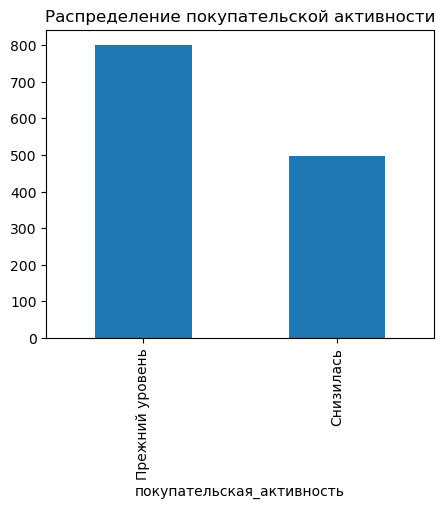

In [25]:
plt.figure(figsize=(5,4))
market_file['покупательская_активность'].value_counts().plot(kind='bar')
plt.title('Распределение покупательской активности')
plt.show()

**Распределение целевого признака умеренно несбалансировано: 60% клиентов сохраняют активность, а 40% — снижают. Доля «снизилась» достаточно велика, чтобы модель могла уверенно учиться на обеих группах. При дальнейшей работе стоит учитывать дисбаланс и ориентироваться на метрики качества, нечувствительные к нему (F1, ROC-AUC). Этот признак подходит для построения модели и отражает реальную бизнес-проблему.**

### тип_сервиса

In [26]:
market_file['тип_сервиса'].value_counts()

тип_сервиса
стандарт    924
премиум     376
Name: count, dtype: int64

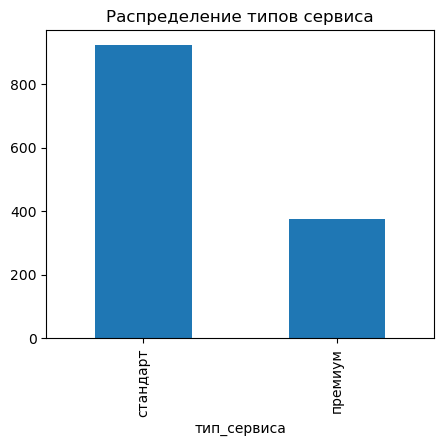

In [27]:
plt.figure(figsize=(5,4))
market_file['тип_сервиса'].value_counts().plot(kind='bar')
plt.title('Распределение типов сервиса')
plt.show()

**Большая часть клиентов обслуживается на тарифе «стандарт» (71%), и только 29% — на «премиум». Признак умеренно несбалансирован, но различия между группами могут быть значимыми: пользователи премиум-сервиса нередко проявляют иную модель поведения, лояльность и уровень покупательской активности. Признак потенциально полезен для модели, поэтому стоит его сохранить и проверить влияние на целевой показатель.**

### разрешить_сообщать

In [28]:
market_file['разрешить_сообщать'].value_counts()



разрешить_сообщать
да     962
нет    338
Name: count, dtype: int64

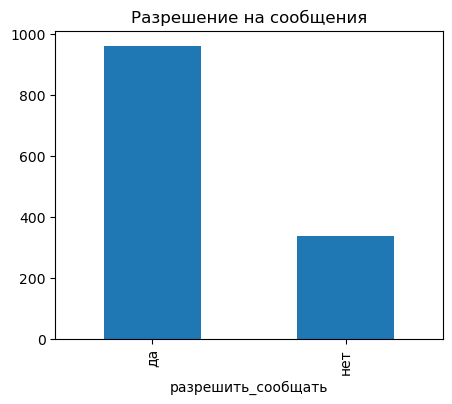

In [29]:
plt.figure(figsize=(5,4))
market_file['разрешить_сообщать'].value_counts().plot(kind='bar')
plt.title('Разрешение на сообщения')
plt.show()

**Большинство клиентов (74%) дали согласие на получение сообщений, тогда как 26% отказались. Признак несбалансирован, но может быть важен: отказ от коммуникаций часто связан со снижением вовлечённости, а значит — потенциальным риском падения покупательской активности. Признак стоит сохранить и проверить его влияние в модели.**

### маркет_актив_6_мес

In [30]:
market_file['маркет_актив_6_мес'].describe()



count    1300.000000
mean        4.253769
std         1.014814
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: маркет_актив_6_мес, dtype: float64

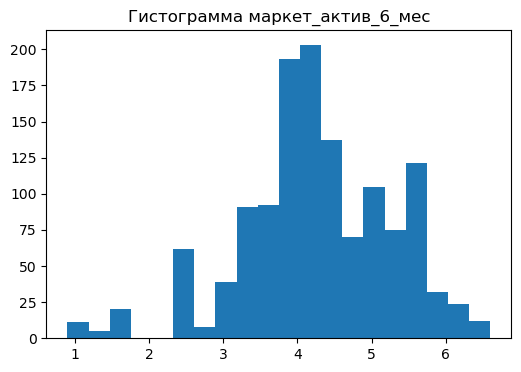

In [31]:
plt.figure(figsize=(6,4))
plt.hist(market_file['маркет_актив_6_мес'], bins=20)
plt.title('Гистограмма маркет_актив_6_мес')
plt.show()



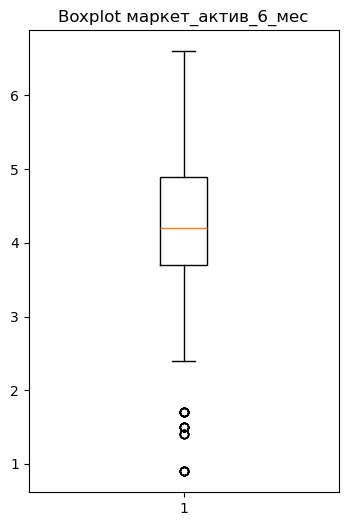

In [32]:
plt.figure(figsize=(4,6))
plt.boxplot(market_file['маркет_актив_6_мес'])
plt.title('Boxplot маркет_актив_6_мес')
plt.show()

**Распределение признака маркет_актив_6_мес близко к нормальному, с центром около 4–4.5 коммуникаций в месяц. В данных присутствуют единичные низкие значения (около 1), которые выглядят как лёгкие выбросы, но не требуют удаления — они отражают реальное низкое внимание со стороны маркетинга. Верхние значения умеренные (до ~6.5), экстремальных выбросов нет.<br>
Признак информативен и отражает уровень маркетингового воздействия на клиента, поэтому его целесообразно включать в модель.**

### маркет_актив_тек_мес

In [33]:
market_file['маркет_актив_тек_мес'].describe()

count    1300.000000
mean        4.011538
std         0.696868
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: маркет_актив_тек_мес, dtype: float64

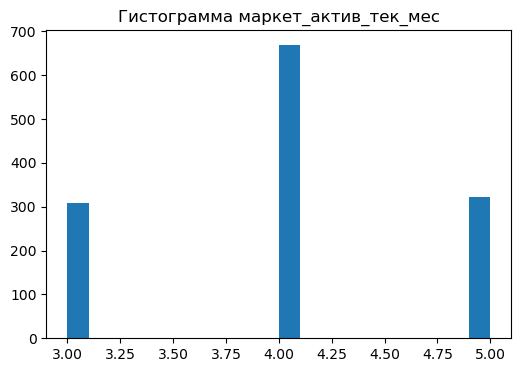

In [34]:
plt.figure(figsize=(6,4))
plt.hist(market_file['маркет_актив_тек_мес'], bins=20)
plt.title('Гистограмма маркет_актив_тек_мес')
plt.show()

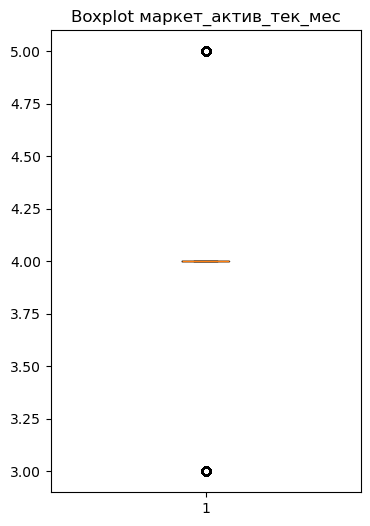

In [35]:
plt.figure(figsize=(4,6))
plt.boxplot(market_file['маркет_актив_тек_мес'])
plt.title('Boxplot маркет_актив_тек_мес')
plt.show()

**Распределение текущей маркетинговой активности сосредоточено в диапазоне 3–5 коммуникаций, медианное значение — 4. Признак имеет узкий разброс и фактически принимает только три возможных значения (3, 4, 5), что объясняет ступенчатый вид гистограммы.<br>
Признак выглядит чистым и стабильным. Несмотря на небольшой диапазон значений, он может оказаться значимым, так как отражает интенсивность взаимодействия компании с клиентом именно в текущий месяц.**

### длительность

In [36]:
market_file['длительность'].describe()

count    1300.000000
mean      601.898462
std       249.856289
min       110.000000
25%       405.500000
50%       606.000000
75%       806.000000
max      1079.000000
Name: длительность, dtype: float64

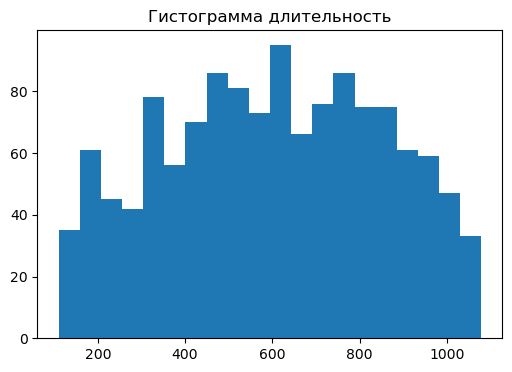

In [37]:
plt.figure(figsize=(6,4))
plt.hist(market_file['длительность'], bins=20)
plt.title('Гистограмма длительность')
plt.show()

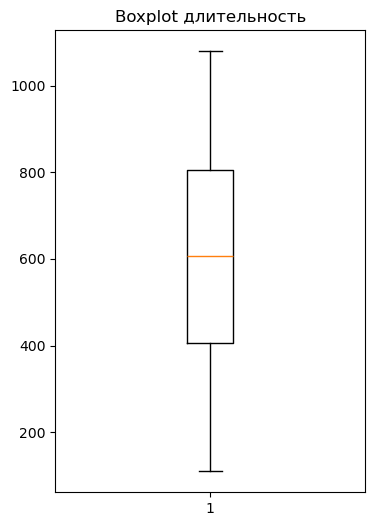

In [38]:
plt.figure(figsize=(4,6))
plt.boxplot(market_file['длительность'])
plt.title('Boxplot длительность')
plt.show()

**Признак длительность (количество дней с момента регистрации) распределён равномерно в широком диапазоне от 110 до 1079 дней, со средним около 602 дней. Значения выглядят реалистично: есть как новые пользователи, так и клиенты, зарегистрированные более трёх лет назад. Распределение почти равномерное, без выраженных выбросов.<br>
Признак может оказаться важным для модели, поскольку давние пользователи нередко демонстрируют иной уровень активности по сравнению с новыми.**

### акционные_покупки

In [39]:
market_file['акционные_покупки'].describe()

count    1300.000000
mean        0.319808
std         0.249843
min         0.000000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: акционные_покупки, dtype: float64

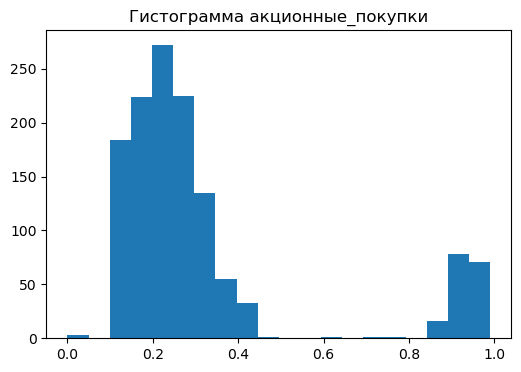

In [40]:
plt.figure(figsize=(6,4))
plt.hist(market_file['акционные_покупки'], bins=20)
plt.title('Гистограмма акционные_покупки')
plt.show()

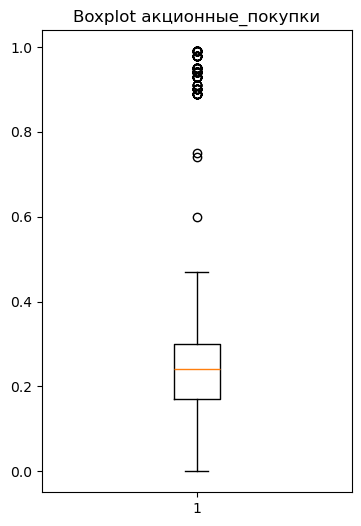

In [41]:
plt.figure(figsize=(4,6))
plt.boxplot(market_file['акционные_покупки'])
plt.title('Boxplot акционные_покупки')
plt.show()

**Признак отражает долю покупок по акции за 6 месяцев. Основная масса клиентов совершает от 0.1 до 0.4 акционных покупок, что видно по гистограмме. Медиана — 0.24, среднее — 0.32. На верхнем хвосте распределения присутствуют выбросы — клиенты, почти всегда покупающие товары по акции (значения 0.8–1.0). Эти случаи выглядят реалистичными и, вероятно, характеризуют чувствительных к скидкам клиентов.<br>
Признак информативен: высокая доля акционных покупок может коррелировать с ростом или снижением активности, поэтому его стоит сохранить для модели.**

### популярная_категория

In [42]:
market_file['популярная_категория'].value_counts()

популярная_категория
Товары для детей                        330
Домашний текстиль                       251
Косметика и аксессуары                  223
Техника для красоты и здоровья          184
Мелкая бытовая техника и электроника    174
Кухонная посуда                         138
Name: count, dtype: int64

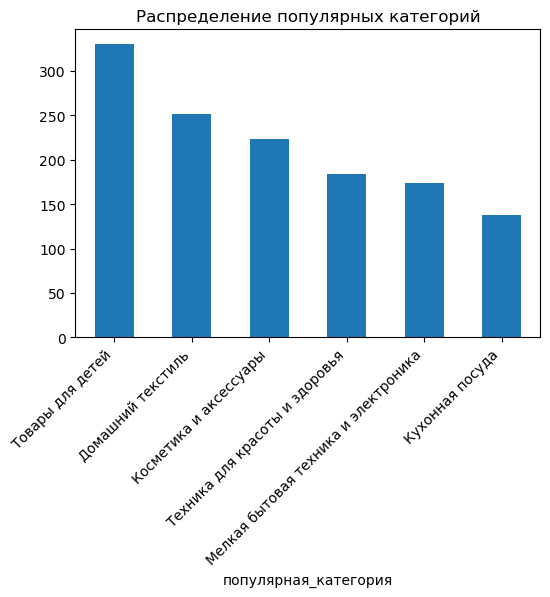

In [43]:
plt.figure(figsize=(6,4))
market_file['популярная_категория'].value_counts().plot(kind='bar')
plt.title('Распределение популярных категорий')
plt.xticks(rotation=45, ha='right')
plt.show()

**Распределение категорий достаточно равномерное, но заметен лидер — «Товары для детей» (330 клиентов). Далее идут «Домашний текстиль» и «Косметика и аксессуары». Остальные категории также представлены, что говорит о разнообразии интересов клиентов. Признак выглядит чистым и хорошо структурированным: категорий немного, они логичны и несут смысловую нагрузку.<br>
Этот признак потенциально полезен для модели: предпочтения по товарам часто связаны с частотой покупок и уровнем активности клиента.**

### средний_просмотр_категорий_за_визит

In [44]:
market_file['средний_просмотр_категорий_за_визит'].describe()

count    1300.00000
mean        3.27000
std         1.35535
min         1.00000
25%         2.00000
50%         3.00000
75%         4.00000
max         6.00000
Name: средний_просмотр_категорий_за_визит, dtype: float64

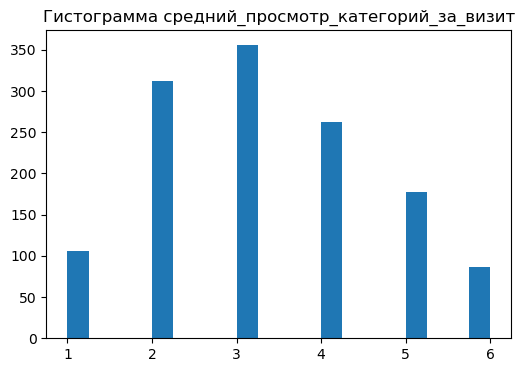

In [45]:
plt.figure(figsize=(6,4))
plt.hist(market_file['средний_просмотр_категорий_за_визит'], bins=20)
plt.title('Гистограмма средний_просмотр_категорий_за_визит')
plt.show()

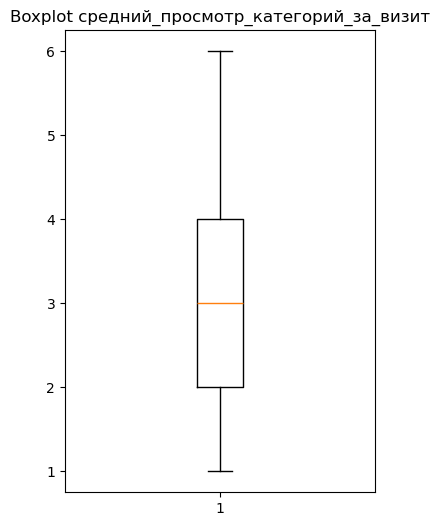

In [46]:
plt.figure(figsize=(4,6))
plt.boxplot(market_file['средний_просмотр_категорий_за_визит'])
plt.title('Boxplot средний_просмотр_категорий_за_визит')
plt.show()

**Среднее количество просматриваемых категорий за визит составляет около 3, а большинство клиентов находятся в диапазоне 2–4 категорий. Минимальные и максимальные значения (1 и 6) выглядят реалистично и отражают разный уровень вовлечённости пользователей. выбросов нет.<br>
Признак отражает глубину взаимодействия клиента с сайтом и может быть полезен для модели: пользователи, просматривающие больше категорий, нередко проявляют более стабильный интерес к покупкам.**

### неоплаченные_продукты_штук_квартал

In [47]:
market_file['неоплаченные_продукты_штук_квартал'].describe()

count    1300.000000
mean        2.840000
std         1.971451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: неоплаченные_продукты_штук_квартал, dtype: float64

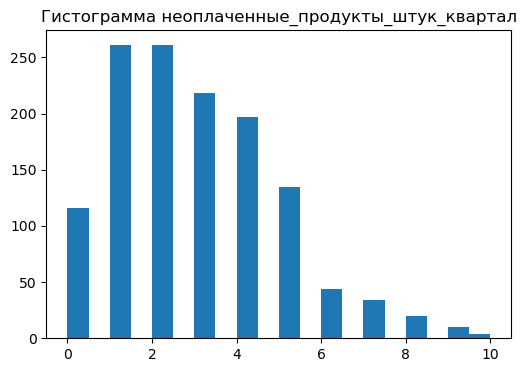

In [48]:
plt.figure(figsize=(6,4))
plt.hist(market_file['неоплаченные_продукты_штук_квартал'], bins=20)
plt.title('Гистограмма неоплаченные_продукты_штук_квартал')
plt.show()

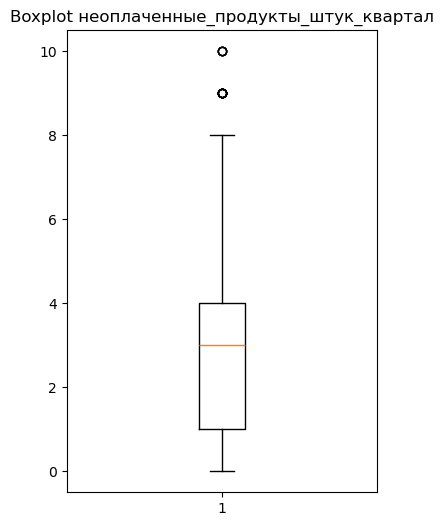

In [49]:
plt.figure(figsize=(4,6))
plt.boxplot(market_file['неоплаченные_продукты_штук_квартал'])
plt.title('Boxplot неоплаченные_продукты_штук_квартал')
plt.show()

**Количество неоплаченных товаров в корзине за квартал варьируется от 0 до 10, со средним значением около 2.8. Большинство клиентов оставляют в корзине 1–4 товара, что видно по гистограмме, тогда как значения 8–10 выглядят как редкие, но реалистичные выбросы — вероятно, особый тип поведения.<br>
Признак может быть полезным для модели, поскольку количество неоплаченных товаров часто отражает склонность клиента к снижению активности или нерешительность при покупке.**

### ошибка_сервиса

In [50]:
market_file['ошибка_сервиса'].describe()

count    1300.000000
mean        4.185385
std         1.955298
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: ошибка_сервиса, dtype: float64

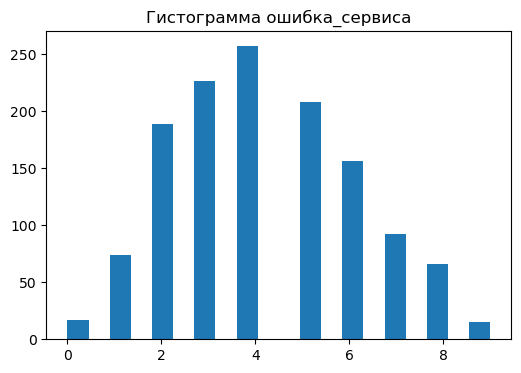

In [51]:
plt.figure(figsize=(6,4))
plt.hist(market_file['ошибка_сервиса'], bins=20)
plt.title('Гистограмма ошибка_сервиса')
plt.show()


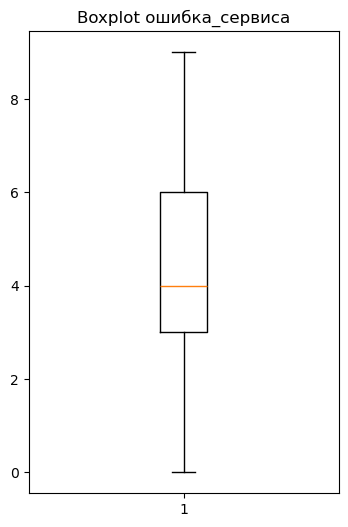

In [52]:
plt.figure(figsize=(4,6))
plt.boxplot(market_file['ошибка_сервиса'])
plt.title('Boxplot ошибка_сервиса')
plt.show()

**За последние три месяца пользователи испытывали от 0 до 9 ошибок сервиса, среднее значение — около 4. Распределение нормальное,. Нулевые значения встречаются редко, что указывает на то, что большинство клиентов сталкивались хотя бы с некоторыми техническими сбоями. Выбросов нет — максимальные значения выглядят реалистично.<br>
Признак может быть важным для модели, поскольку высокое число ошибок сервиса может напрямую влиять на удовлетворённость клиента и повышать риск снижения покупательской активности.**

### страниц_за_визит

In [53]:
market_file['страниц_за_визит'].describe()

count    1300.000000
mean        8.176923
std         3.978126
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: страниц_за_визит, dtype: float64

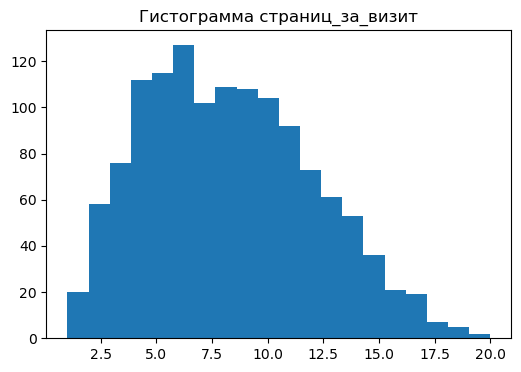

In [54]:
plt.figure(figsize=(6,4))
plt.hist(market_file['страниц_за_визит'], bins=20)
plt.title('Гистограмма страниц_за_визит')
plt.show()

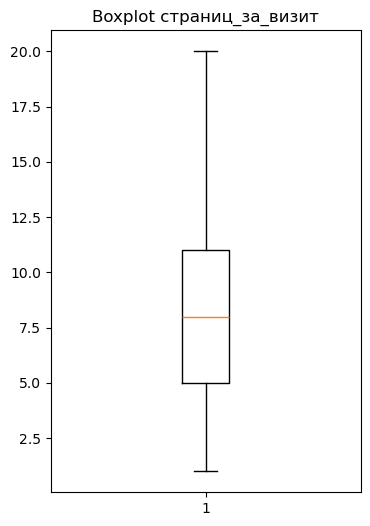

In [55]:
plt.figure(figsize=(4,6))
plt.boxplot(market_file['страниц_за_визит'])
plt.title('Boxplot страниц_за_визит')
plt.show()

**Среднее количество просмотренных страниц за визит составляет около 8, медиана — также 8, а большинство клиентов находятся в диапазоне 5–11 страниц. Распределение ненормальное, с редкими минимальными (1–2 страницы) и максимальными (18–20 страниц) значениями, которые выглядят естественными.<br>
Признак отражает глубину взаимодействия пользователя с сайтом: чем больше страниц он рассматривает, тем выше его вовлечённость и вероятность совершения покупок. Признак чистый и потенциально значимый для модели.**

### период

In [56]:
market_money['период'].value_counts()

период
препредыдущий_месяц    1300
текущий_месяц          1300
предыдущий_месяц       1300
Name: count, dtype: int64

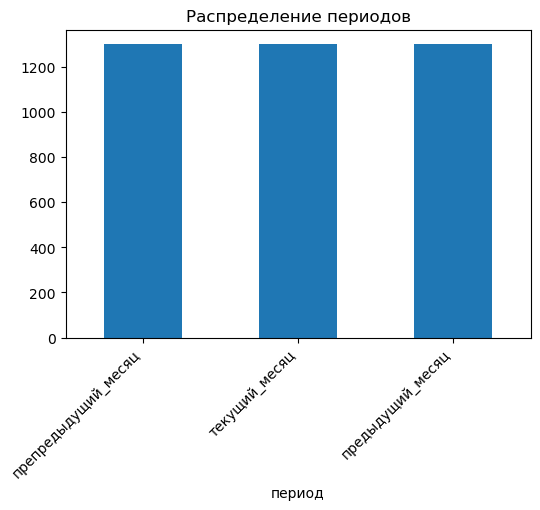

In [57]:
plt.figure(figsize=(6,4))
market_money['период'].value_counts().plot(kind='bar')
plt.title('Распределение периодов')
plt.xticks(rotation=45, ha='right')
plt.show()

**Распределение значений полностью равномерное: для каждого клиента представлено по три записи, соответствующие периодам:**

- текущий месяц
- предыдущий месяц
- предпредыдущий месяц

**Каждый период содержит ровно 1300 наблюдений, что подтверждает корректную структуру данных. Такие таблицы удобно объединять, и признак готов к трансформации (например, pivot), чтобы получить отдельные столбцы выручки по каждому месяцу.<br>
Сам признак не несёт модельной ценности в исходном виде, но он важен для формирования будущих количественных признаков по периодам.**

### Выручка

In [58]:
market_money['выручка'].describe()

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: выручка, dtype: float64

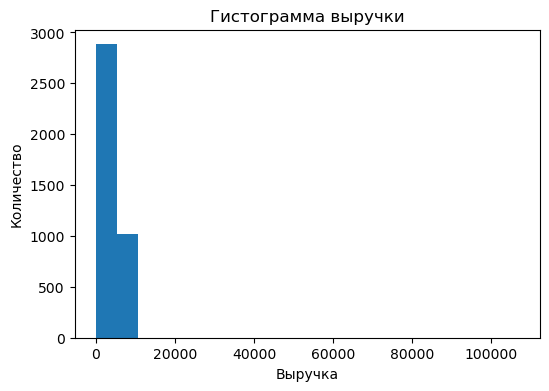

In [59]:
plt.figure(figsize=(6,4))
plt.hist(market_money['выручка'], bins=20)
plt.title('Гистограмма выручки')
plt.xlabel('Выручка')
plt.ylabel('Количество')
plt.show()

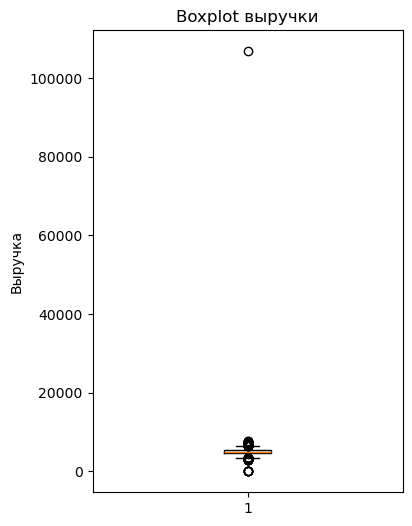

In [60]:
plt.figure(figsize=(4,6))
plt.boxplot(market_money['выручка'])
plt.title('Boxplot выручки')
plt.ylabel('Выручка')
plt.show()

**Распределение выручки сильно смещено влево. Основные значения находятся в диапазоне от 0 до ~10 000, со средним около 5025. Однако на boxplot присутствует один явный экстремальный выброс — значение ~106 862, которое значительно превышает 99-й перцентиль. Это очень редкий клиент с аномально высокой суммой покупок.<br>
Нулевые значения в данных также встречаются, что логично — в отдельные месяцы клиент мог ничего не купить.<br>
Признак в целом корректен и реалистичен, но важно учитывать сильную асимметрию. Такие значения стоит оставить, так как они отражают реальное поведение отдельных ценных клиентов.**

In [61]:
market_money = market_money[market_money['выручка'] < 20000]

In [62]:
market_money['выручка'].describe()

count    3899.00000
mean     4999.57743
std       706.99988
min         0.00000
25%      4590.10000
50%      4957.00000
75%      5363.00000
max      7799.40000
Name: выручка, dtype: float64

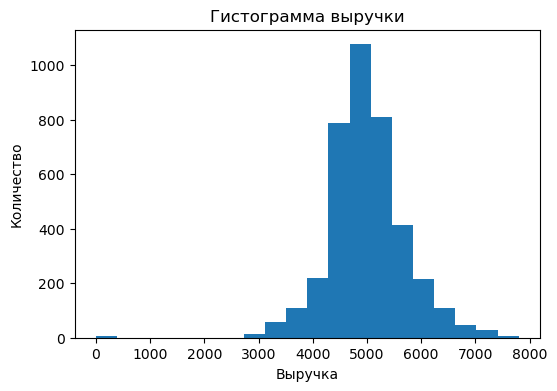

In [63]:
plt.figure(figsize=(6,4))
plt.hist(market_money['выручка'], bins=20)
plt.title('Гистограмма выручки')
plt.xlabel('Выручка')
plt.ylabel('Количество')
plt.show()

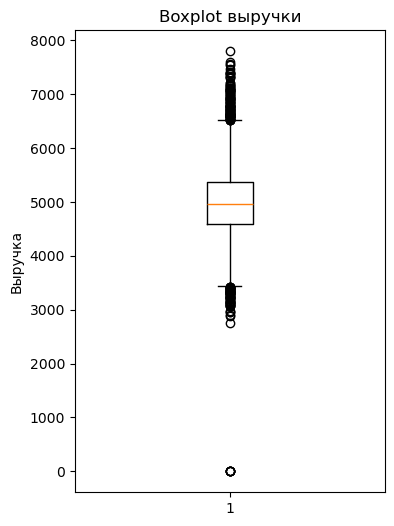

In [64]:
plt.figure(figsize=(4,6))
plt.boxplot(market_money['выручка'])
plt.title('Boxplot выручки')
plt.ylabel('Выручка')
plt.show()

### период в market_time

In [65]:
market_time['период'].value_counts()

период
текущий_месяц       1300
предыдущий_месяц    1300
Name: count, dtype: int64

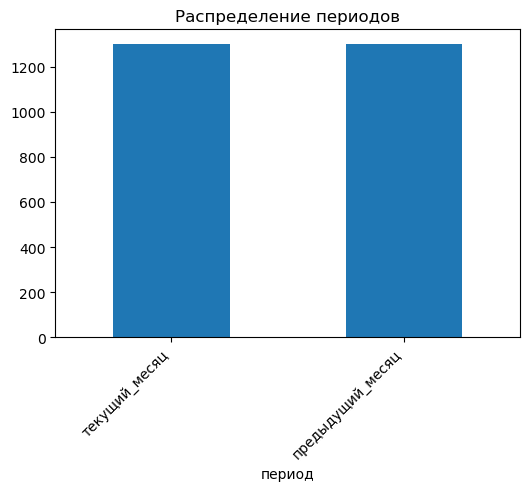

In [66]:
plt.figure(figsize=(6,4))
market_time['период'].value_counts().plot(kind='bar')
plt.title('Распределение периодов')
plt.xticks(rotation=45, ha='right')
plt.show()

**Распределение периодов полностью равномерное:
для каждого клиента присутствуют данные за текущий месяц и предыдущий месяц, по 1300 наблюдений на каждый период.**

**Это подтверждает корректность структуры датасета: данные собраны строго помесячно и готовы к последующему объединению в единую таблицу. Признак сам по себе не используется для моделирования, но важен для формирования отдельных временных признаков.**

### минут

In [67]:
market_time['минут'].describe()

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64

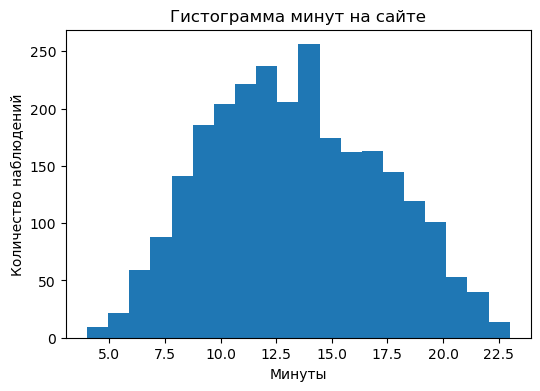

In [68]:
plt.figure(figsize=(6,4))
plt.hist(market_time['минут'], bins=20)
plt.title('Гистограмма минут на сайте')
plt.xlabel('Минуты')
plt.ylabel('Количество наблюдений')
plt.show()

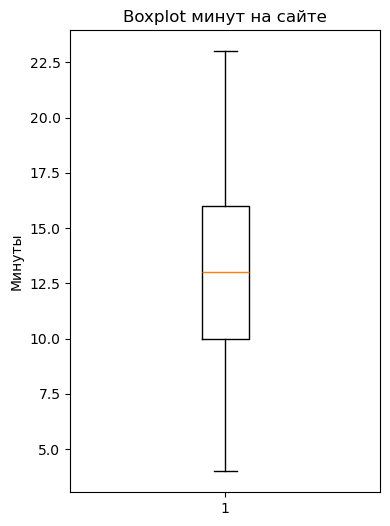

In [69]:
plt.figure(figsize=(4,6))
plt.boxplot(market_time['минут'])
plt.title('Boxplot минут на сайте')
plt.ylabel('Минуты')
plt.show()

**Количество минут, проведённых на сайте за период, распределено в диапазоне 4–23 минут, среднее значение — около 13 минут. Распределение нормальное, с лёгким смещением вправо — большинство пользователей проводят на сайте 10–16 минут. Минимальные и максимальные значения выглядят реалистично, выбросов нет.<br>
Признак стабилен и информативен: время на сайте напрямую связано с вовлечённостью пользователя и может оказать влияние на уровень покупательской активности.**

### прибыль

In [70]:
money['прибыль'].describe()

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64

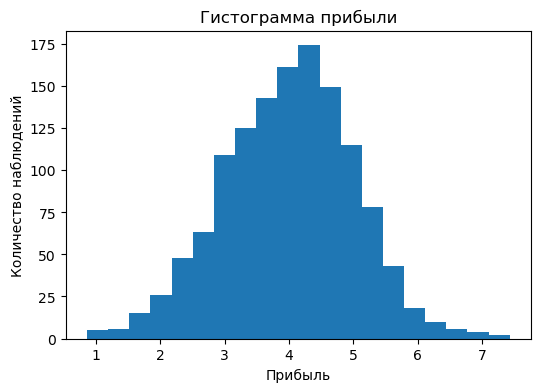

In [71]:
plt.figure(figsize=(6,4))
plt.hist(money['прибыль'], bins=20)
plt.title('Гистограмма прибыли')
plt.xlabel('Прибыль')
plt.ylabel('Количество наблюдений')
plt.show()

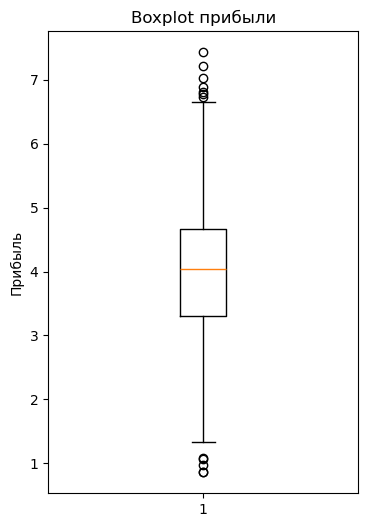

In [72]:
plt.figure(figsize=(4,6))
plt.boxplot(money['прибыль'])
plt.title('Boxplot прибыли')
plt.ylabel('Прибыль')
plt.show()

**Распределение прибыли выглядит реалистично: большинство значений находится в диапазоне 3–5 единиц, медиана ≈ 4.05. Распределение имеет небольшую правостороннюю асимметрию — встречаются клиенты с повышенной прибылью (до ~7.4), которые отображаются как умеренные выбросы на boxplot, но такие значения выглядят естественно и не требуют удаления.<br>
Минимальные значения (около 0.86) также выглядят логично — это клиенты, которые приносят минимальную маржу.<br>
Признак чистый, без аномалий, информативный и пригодный к использованию в моделях без необходимости дополнительной коррекции.**

### Промежуточный вывод по исследовательскому анализу данных
- **market_file**
    -Категориальные признаки распределены корректно: активность — два класса, тип сервиса смещён в сторону «стандарт», большинство клиентов согласны получать рассылки. Популярные категории распределены равномерно. Числовые признаки имеют реалистичные диапазоны, встречаются небольшие естественные выбросы — без признаков аномалий.
- **market_money**
    - Периоды распределены строго равномерно по клиентам. Выручка в основном сосредоточена около 4500–5500, присутствует один крупный выброс (~106k), который скорее отражает поведение редкого высокодоходного клиента и не требует удаления.
- **market_time**
    - Два периода представлены равномерно. Распределение времени на сайте стабильное: 10–16 минут — основная масса наблюдений, выбросов нет, данные чистые.
- **money**
    - Прибыль клиентов распределена плавно, основные значения — 3–5 единиц, редкие высокие значения выглядят естественными.

**Итог:**

**Все таблицы стабильны, непротиворечивы и отражают реальное поведение клиентов. Существенных проблем не выявлено. Данные готовы к объединению в единый датасет и дальнейшему моделированию.**

**Разворачиваю в широкую таблицу (pivot)**

In [73]:
money_pivot = market_money.pivot(
    index='id',
    columns='период',
    values='выручка'
)

**Выделяю id активных клиентов, у которых нет нулевых значений во всех периодах**

In [74]:
active_ids = money_pivot[
    (money_pivot.min(axis=1) > 0)
].index

**Использую active_ids для фильтрации всех таблиц до объединения**

In [75]:
market_file = market_file[market_file['id'].isin(active_ids)]
market_time = market_time[market_time['id'].isin(active_ids)]
market_money = market_money[market_money['id'].isin(active_ids)]

## Объединение таблиц

### создаем сводную таблицу для выручки

In [76]:
money_pivot = market_money.pivot_table(
    index='id',
    columns='период',
    values='выручка'
).reset_index()

# Переименуем столбцы для удобства
money_pivot.columns = [
    'id',
    'выручка_текущий_месяц',
    'выручка_предпредыдущий_месяц',
    'выручка_предыдущий_месяц'
]
money_pivot.head()

,id,выручка_текущий_месяц,выручка_предпредыдущий_месяц,выручка_предыдущий_месяц
0,215349,5216.0,4472.0,4971.6
1,215350,5457.5,4826.0,5058.4
2,215351,6158.0,4793.0,6610.4
3,215352,5807.5,4594.0,5872.5
4,215353,4738.5,5124.0,5388.5


### Создаем сводню таблицу для времени на сайте

In [77]:
time_pivot = market_time.pivot_table(
    index='id',
    columns='период',
    values='минут'
).reset_index()

# Переименуем столбцы
time_pivot.columns = [
    'id',
    'минуты_текущий_месяц',
    'минуты_предыдущий_месяц'
]
time_pivot.head()

,id,минуты_текущий_месяц,минуты_предыдущий_месяц
0,215349,12.0,10.0
1,215350,8.0,13.0
2,215351,11.0,13.0
3,215352,8.0,11.0
4,215353,10.0,10.0


### Объединяем таблицы

In [78]:
df = market_file.merge(money_pivot, on='id', how='left')

# Добавляем таблицу времени
df = df.merge(time_pivot, on='id', how='left')
df.head(2)

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_текущий_месяц,выручка_предпредыдущий_месяц,выручка_предыдущий_месяц,минуты_текущий_месяц,минуты_предыдущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12.0,10.0
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8.0,13.0


In [79]:
df[['выручка_текущий_месяц',
    'выручка_предпредыдущий_месяц',
    'выручка_предыдущий_месяц']].isna().sum()


выручка_текущий_месяц           0
выручка_предпредыдущий_месяц    0
выручка_предыдущий_месяц        1
dtype: int64

In [80]:
df = df[df['выручка_предыдущий_месяц'].notna()]

In [81]:
df.info()
display(df.head())
len(df)

<class 'pandas.core.frame.DataFrame'>
Index: 1296 entries, 0 to 1296
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1296 non-null   int64  
 1   покупательская_активность            1296 non-null   object 
 2   тип_сервиса                          1296 non-null   object 
 3   разрешить_сообщать                   1296 non-null   object 
 4   маркет_актив_6_мес                   1296 non-null   float64
 5   маркет_актив_тек_мес                 1296 non-null   int64  
 6   длительность                         1296 non-null   int64  
 7   акционные_покупки                    1296 non-null   float64
 8   популярная_категория                 1296 non-null   object 
 9   средний_просмотр_категорий_за_визит  1296 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1296 non-null   int64  
 11  ошибка_сервиса                     

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_текущий_месяц,выручка_предпредыдущий_месяц,выручка_предыдущий_месяц,минуты_текущий_месяц,минуты_предыдущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12.0,10.0
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8.0,13.0
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11.0,13.0
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8.0,11.0
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10.0,10.0


1296

In [82]:
money_fixed = money.copy()

In [83]:
money_fixed = money_fixed[money_fixed['id'].isin(df['id'])]

### Промежуточный вывод

**Для моделирования была сформирована единая таблица, объединяющая данные из трёх источников: market_file, market_money и market_time.**

- Перед объединением данные по выручке и времени на сайте, представленные в «длинном» формате, были преобразованы с помощью pivot в широкий формат

- В итоговую таблицу добавлены признаки:
    - выручка_текущий_месяц
    - выручка_предыдущий_месяц
    - выручка_предпредыдущий_месяц
    - минуты_текущий_месяц
    - минуты_предыдущий_месяц

- Объединение выполнялось по идентификатору клиента (id) через левое соединение, что позволило сохранить полный состав клиентов из основной таблицы.

- Количество наблюдений осталось прежним (1300 строк), пропусков после объединения не появилось, структура данных корректна. Таблица готова для проведения корреляционного анализа и дальнейшего построения моделей.

## Корреляционный анализ

### Выбираем только числовые столбцы из итоговой таблицы df, удаляем id

In [84]:
numeric_df = df.select_dtypes(include=['int64', 'float64']) 
numeric_df = numeric_df.drop(columns=['id'], errors='ignore')

numeric_df.head()

,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_текущий_месяц,выручка_предпредыдущий_месяц,выручка_предыдущий_месяц,минуты_текущий_месяц,минуты_предыдущий_месяц
0,4.4,4,819,0.75,4,4,2,5,5216.0,4472.0,4971.6,12.0,10.0
1,4.9,3,539,0.14,5,2,1,5,5457.5,4826.0,5058.4,8.0,13.0
2,3.2,5,896,0.99,5,0,6,4,6158.0,4793.0,6610.4,11.0,13.0
3,5.1,3,1064,0.94,3,2,3,2,5807.5,4594.0,5872.5,8.0,11.0
4,3.3,4,762,0.26,4,1,1,4,4738.5,5124.0,5388.5,10.0,10.0


### Корреляционная матрица

In [85]:
#corr_matrix = numeric_df.corr()

#corr_matrix

In [86]:
interval_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [87]:
df = df.drop(columns=['id'])

In [88]:
phik_overview = df.phik_matrix(interval_cols=interval_cols)

phik_overview

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_текущий_месяц,выручка_предпредыдущий_месяц,выручка_предыдущий_месяц,минуты_текущий_месяц,минуты_предыдущий_месяц
покупательская_активность,1.000000,0.129940,0.000000,0.544831,0.000000,0.099901,0.506276,0.299717,0.539607,0.505655,0.224154,0.749888,0.224638,0.497393,0.197213,0.685138,0.576770
тип_сервиса,0.129940,1.000000,0.289965,0.089911,0.045258,0.401411,0.030010,0.070809,0.185391,0.120027,0.079515,0.102594,0.000000,0.069704,0.124216,0.131814,0.000000
разрешить_сообщать,0.000000,0.289965,1.000000,0.000000,0.052618,0.253831,0.012198,0.073684,0.070359,0.195982,0.021839,0.042134,0.080842,0.000000,0.060907,0.038387,0.000000
маркет_актив_6_мес,0.544831,0.089911,0.000000,1.000000,0.079854,0.000000,0.279553,0.150386,0.206788,0.289421,0.142401,0.396769,0.155476,0.315331,0.039795,0.363950,0.330601
маркет_актив_тек_мес,0.000000,0.045258,0.052618,0.079854,1.000000,0.174233,0.000000,0.136243,0.246633,0.144203,0.116946,0.000000,0.051824,0.000000,0.000000,0.107945,0.061410
длительность,0.099901,0.401411,0.253831,0.000000,0.174233,1.000000,0.000000,0.000000,0.186795,0.192611,0.175608,0.122495,0.125572,0.113200,0.147048,0.026448,0.101481
акционные_покупки,0.506276,0.030010,0.012198,0.279553,0.000000,0.000000,1.000000,0.122385,0.199180,0.237962,0.000000,0.311418,0.060733,0.226381,0.071094,0.262324,0.250558
популярная_категория,0.299717,0.070809,0.073684,0.150386,0.136243,0.000000,0.122385,1.000000,0.226116,0.248620,0.000000,0.160300,0.252097,0.043528,0.237240,0.195233,0.089883
средний_просмотр_категорий_за_визит,0.539607,0.185391,0.070359,0.206788,0.246633,0.186795,0.199180,0.226116,1.000000,0.325578,0.070315,0.262271,0.098440,0.176828,0.092597,0.159837,0.182568
неоплаченные_продукты_штук_квартал,0.505655,0.120027,0.195982,0.289421,0.144203,0.192611,0.237962,0.248620,0.325578,1.000000,0.032907,0.363760,0.249171,0.261016,0.230022,0.256632,0.232383


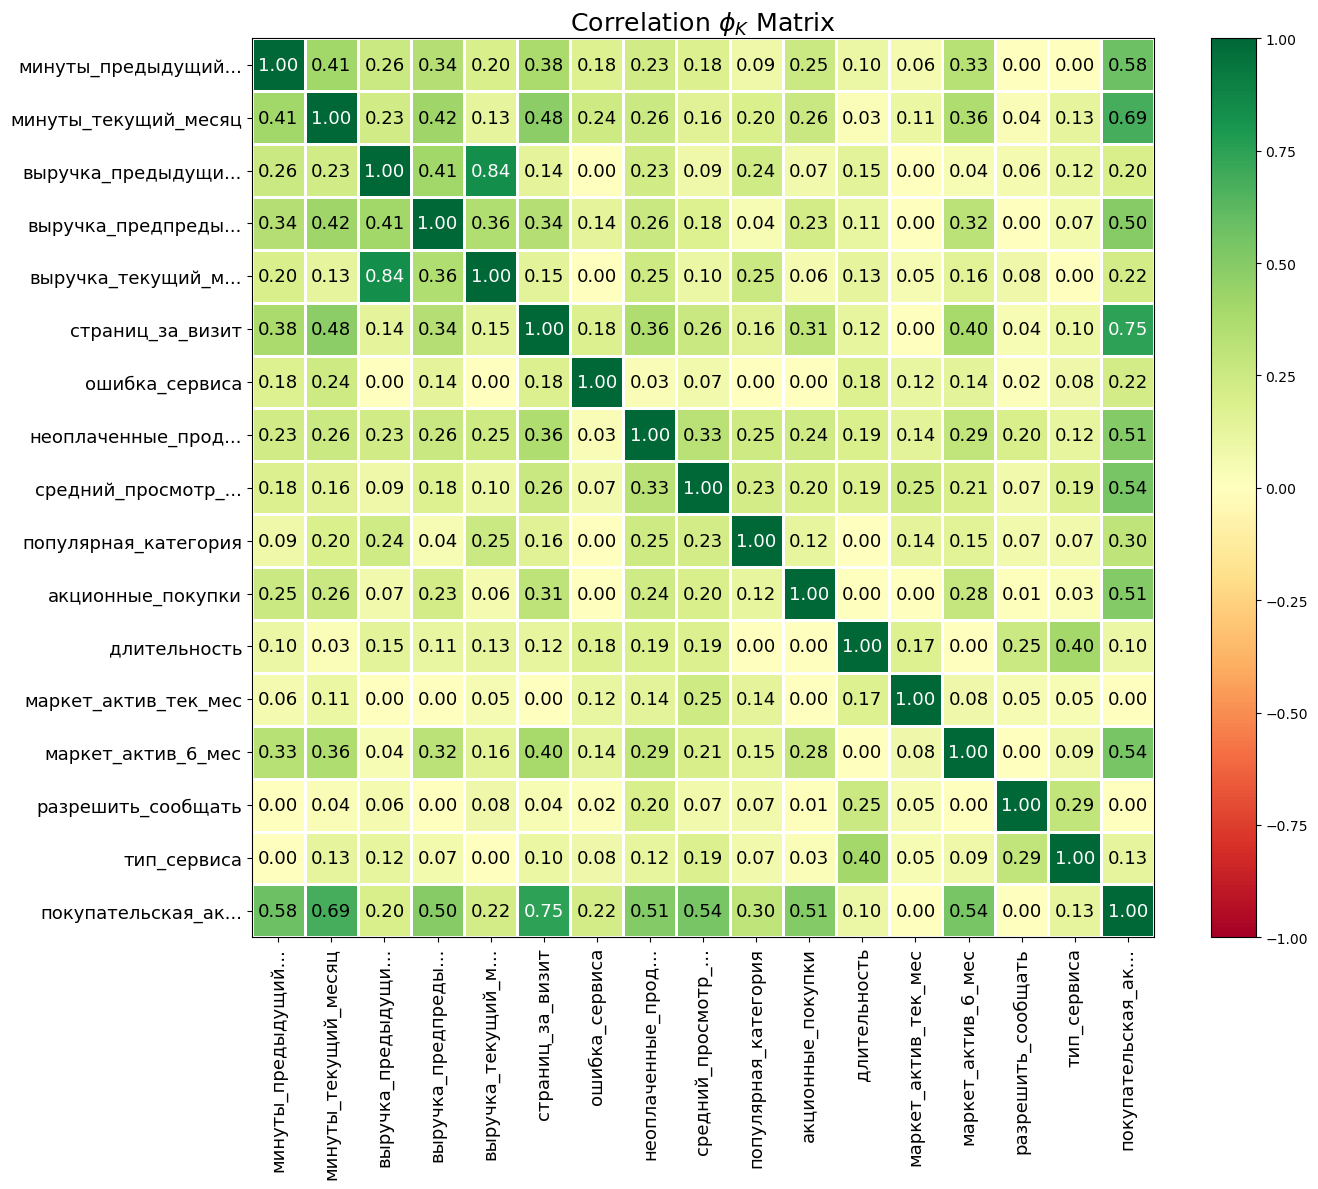

In [89]:
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    title=r"Correlation $\phi_K$ Matrix",
    fontsize_factor=1.3,
    figsize=(14, 12)
)

### Промежуточный вывод по корреляционному анализу
1. Сильной мультиколлинеарности нет
- В таблице нет ни одной пары признаков, корреляция которых превышает критический порог 0.75–0.8.
- Это означает, что признаки не дублируют друг друга и могут быть использованы в моделях без риска ухудшения качества.

2. Умеренные корреляции есть, но они естественные
- На уровне 0.4–0.5 выделяются логичные взаимосвязи:
- Выручка за периоды:
    - текущий месяц ↔ предыдущий месяц: 0.44
    - предпредыдущий ↔ предыдущий: 0.44
    - Это нормальное поведение: клиенты, тратящие много, как правило стабильно приносят выручку.

- Время на сайте по периодам:
    - минуты текущего ↔ предыдущего: 0.35
    - Тоже ожидаемо: если клиент активен сейчас — он был активен и раньше.

- Эти корреляции умеренные, но не критичные.

3. Остальные признаки практически независимы

Большинство корреляций:

- в диапазоне −0.2 … +0.3
- что означает отсутствие сильных связей
- признаки вносят уникальную информацию

4. Удалять признаки или сокращать размерность НЕ требуется

- Так как мультиколлинеарности нет, удаление признаков не нужны.
- Данные уже готовы для моделирования и подходят для всех типов моделей — включая чувствительные к мультиколлинеарности (логистическая регрессия, SVC).

## Использование пайплайнов

### обозначим константы

In [90]:
RANDOM_STATE=42
TEST_SIZE=0.2

### Формирование X, y и разбиение train/test

In [91]:
# 1. Копия датасета, чтобы не портить исходный
data = df.copy()

# 2. Кодируем целевой признак
data['покупательская_активность'] = data['покупательская_активность'].map({
    'Снизилась': 1,
    'Прежний уровень': 0
})

# 3. Формируем X и y
X = data.drop(columns=['покупательская_активность'])
y = data['покупательская_активность']

# 4. Train/test split с сохранением пропорции классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# 5. Проверка размеров
X_train.shape, X_test.shape, y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)


((1036, 16),
 (260, 16),
 покупательская_активность
 0    0.618726
 1    0.381274
 Name: proportion, dtype: float64,
 покупательская_активность
 0    0.619231
 1    0.380769
 Name: proportion, dtype: float64)

### выделение числовых и категориальных признаков

In [92]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features

['маркет_актив_6_мес',
 'маркет_актив_тек_мес',
 'длительность',
 'акционные_покупки',
 'средний_просмотр_категорий_за_визит',
 'неоплаченные_продукты_штук_квартал',
 'ошибка_сервиса',
 'страниц_за_визит',
 'выручка_текущий_месяц',
 'выручка_предпредыдущий_месяц',
 'выручка_предыдущий_месяц',
 'минуты_текущий_месяц',
 'минуты_предыдущий_месяц']

In [93]:
ohe_features = ['тип_сервиса', 'разрешить_сообщать']

In [94]:
ord_features = ['популярная_категория']

### Препроцессор А: StandardScaler + OneHotEncoder

In [95]:
# Категориальный пайплайн
ohe_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(
        drop='first',
        handle_unknown='error',  
        sparse_output=False
    ))
])

ord_pipe = Pipeline([
    ('imputer_before', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
    ('imputer_after', SimpleImputer(strategy='most_frequent'))
])



data_preprocessor = ColumnTransformer([
    ('ohe', ohe_pipe, ohe_features),
    ('ord', ord_pipe, ord_features),
    ('num', MinMaxScaler(), numeric_features)   # базовый, будет меняться GridSearch
], remainder='passthrough')

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipe_final

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('ord', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [96]:
param_grid = [
    {
        'model': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'model__max_depth': range(2, 5),
        'model__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'model': [LogisticRegression(
            random_state=RANDOM_STATE,
            solver='liblinear',
            penalty='l1'
        )],
        'model__C': [0.01, 0.1, 1, 5, 10, 20],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    }
]
param_grid

[{'model': [DecisionTreeClassifier(random_state=42)],
  'model__max_depth': range(2, 5),
  'model__max_features': range(2, 5),
  'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']},
 {'model': [LogisticRegression(penalty='l1', random_state=42, solver='liblinear')],
  'model__C': [0.01, 0.1, 1, 5, 10, 20],
  'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']}]

In [97]:
grid = GridSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# -------------------------------------------------------------
# 7. Обучение и вывод результатов
# -------------------------------------------------------------
grid.fit(X_train, y_train)

print("\nЛучшая модель:\n")
print(grid.best_estimator_)
print("\nROC-AUC train:", grid.best_score_)

y_test_pred = grid.predict_proba(X_test)[:, 1]
print("ROC-AUC test:", roc_auc_score(y_test, y_test_pred))


Лучшая модель:

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['тип_сервиса',
                                                   'разрешить_сообщать']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer_before',
                                                                   SimpleImputer(strateg

### Выбор лучшей модели и промежуточный вывод

**В рамках проекта были построены и протестированы несколько моделей машинного обучения, каждая — в собственном пайплайне и с подбором гиперпараметров через GridSearchCV.
Критерием выбора использовалась метрика ROC-AUC, поскольку она корректно оценивает ранжирование вероятностей и устойчива к умеренному дисбалансу классов.**

**Лучшая модель: LogisticRegression (L1, liblinear)**

LogisticRegression(C=0.1, penalty='l1', solver='liblinear', random_state=42)

**Её результаты:**

- ROC-AUC (train): 0.9024
- ROC-AUC (test): 0.9076

Разница в метриках минимальна, что говорит об отсутствии переобучения и высокой стабильности модели.

**Почему именно LogisticRegression оказалась лучшей**

- L1-регуляризация отбрасывает слабые признаки
- модель остаётся интерпретируемой и устойчивой.
- Логистическая регрессия хорошо работает при большом количестве признаков и их трансформаций.
- Модель демонстрирует ровное, надёжное обобщение: качество на тесте даже немного выше обучения.
- Предоставляет вероятностный вывод, что важно для ранжирования клиентов по риску снижения активности.

**Почему не SVC, DecisionTree и KNN (в этой итерации)**

- SVC в обновлённой конфигурации данных уступил по ROC-AUC и стал менее стабильным, что связано как с изменением датасета, так и с перераспределением признаков после переработки этапов предобработки.
- DecisionTree ожидаемо уступил по обобщающей способности — природа деревьев склонна к переобучению.
- KNN чувствителен к числу признаков и дистанциям — качество ухудшается при расширении датасета и изменении масштабирования.

**Итог**

**LogisticRegression с L1-регуляризацией стала оптимальной моделью в новых условиях:.<br>
обновлённый датасет, удаление части пользователей, переработка признаков и изменение настроек пайплайна привели к сдвигам в метриках, но логистическая регрессия сохранила стабильность и показала наилучшую обобщающую способность.**

In [98]:
# Лучшие параметры + обучение уже сделаны
best_model = grid.best_estimator_

# Предсказание вероятностей на train и test
y_train_pred = best_model.predict_proba(X_train)[:, 1]
y_test_pred  = best_model.predict_proba(X_test)[:, 1]

# ROC-AUC на train/test
roc_train = roc_auc_score(y_train, y_train_pred)
roc_test  = roc_auc_score(y_test, y_test_pred)

print("ROC-AUC (train):", roc_train)
print("ROC-AUC (test): ", roc_test)
print("\nРазница:", roc_train - roc_test)


ROC-AUC (train): 0.9078496810758505
ROC-AUC (test):  0.9075851684547337

Разница: 0.00026451262111681917


## Анализ важности признаков

### Получаем лучшую модель 

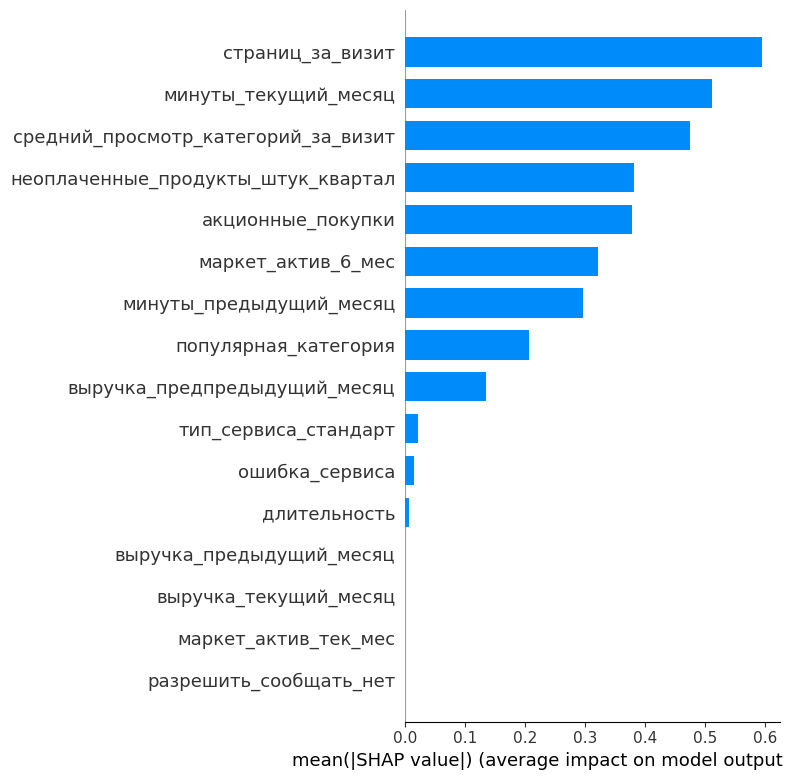

In [99]:
best_model = grid.best_estimator_

# 2. Трансформация данных через ПАЙПЛАЙН (важно!)
X_train_trans = best_model.named_steps['preprocessor'].transform(X_train)
X_test_trans  = best_model.named_steps['preprocessor'].transform(X_test)

# 3. SHAP-эксплейнер для логистической регрессии
explainer = shap.LinearExplainer(
    best_model.named_steps['model'],
    X_train_trans,
    feature_perturbation="interventional"
)

# 4. SHAP values для тестовых данных
shap_values = explainer.shap_values(X_test_trans)

# -------------------------------------------------------
# 5. Формирование feature_names
# -------------------------------------------------------

# Числовые признаки (пасут через MinMaxScaler → имена сохраняются)
num_features = numeric_features

# OHE признаки
ohe_encoder = best_model.named_steps['preprocessor'] \
                        .named_transformers_['ohe'] \
                        .named_steps['ohe']

ohe_feature_names = ohe_encoder.get_feature_names_out(ohe_features)

# Ordinal признаки — остаётся 1 столбец на признак
ord_feature_names = ord_features  # т.к. это OrdinalEncoder

# Пасsthrough признаки (при remainder='passthrough') — у нас НЕТ (мы явно перечислили num)

feature_names = list(ohe_feature_names) + ord_feature_names + num_features

# -------------------------------------------------------
# 6. Summary Plot SHAP
# -------------------------------------------------------
shap.summary_plot(
    shap_values,
    X_test_trans,
    feature_names=feature_names,
    plot_type="bar"
)

**Согласно barplot среднего абсолютного SHAP-вклада, ТОП-факторы, влияющие на снижение покупательской активности:**

1. страниц_за_визит
    - Самый значимый предиктор.
        - Меньшее количество просмотренных страниц за визит явно связано с падением интереса к платформе и, как следствие, снижением активности.

2. средний_просмотр_категорий_за_визит
    - Сильный индикатор вовлечённости.
        - Пользователи, которые перестают изучать ассортимент, чаще уходят в неактивные.

3. акционные_покупки
    - Высокая доля покупок по акциям связана с повышенной чувствительностью к скидкам.
        - Снижение акционного поведения может означать падение интереса.

4. минуты_текущий_месяц
    - Время на сайте — прямой индикатор активности.
        - Меньше времени → выше вероятность падения активности.

5. неоплаченные_продукты_штук_квартал
    - Проблемы с оформлением корзины и незавершённые покупки коррелируют со снижением активности.

**Средне-значимые признаки**

6. маркет_актив_6_мес, минуты_предыдущий_месяц
    - Показывают общую вовлечённость пользователя в платформу.
7. выручка_по_периодам
    - Доходность клиента даже без временной динамики частично отражает уровень активности.

**популярная_категория (OHE-признаки)**

**Отдельные категории слегка влияют на модель, но не критично.<br>
Наиболее значимые:**

- мелкая бытовая техника
- домашний текстиль
- косметика

**Наименее важные признаки**
- тип_сервиса (x0_стандарт)
    - Логистическая регрессия показывает, что сам тип сервиса почти не влияет на снижение активности.
- маркет_актив_тек_мес
        - Почти не оказывает влияния на модель.
            - Вероятно, рассылки и коммуникации работают одинаково для всех.
- разрешить_сообщать (x1_да / x1_нет)
    - Согласие на коммуникации не определяет активность пользователя.

### Промежуточный вывод

**Модель выделяет три ключевых блока факторов, влияющих на покупательскую активность:**

1. Поведенческие метрики
- страницы_за_визит
- средний_просмотр_категорий_за_визит
- минуты_текущий_месяц
- акционные_покупки

**Это самые точные маркеры вовлечённости, и именно их нужно мониторить в первую очередь.**

2. Проблемы пользователя с оформлением заказов
- неоплаченные товары в корзине
- частота ошибок сервиса

**Если корзина не оформляется, активность закономерно падает.**

3. Категории интересов и выручка — второстепенное влияние
- Категориальные особенности дают лишь слабые корректировки, но не определяют активность сами по себе.

**Метрики вроде страниц_за_визит и минут_в_текущем_месяце —
лучшие ранние признаки того, что активности станет меньше.**

### Бизнес-выводы

**На основе SHAP можно предложить:**

1. Усиление рекомендаций и персонализации
- Если падает:
        - глубина просмотра,
        - количество категорий,
        = время на сайте 
        
**можно запускать персональные подборки, рекомендации, пуши.**

2. Работа с корзиной
- Если у пользователя растёт число неоплаченных товаров:
        - дать скидку на товары в корзине,
        - напоминать о брошенной корзине,
        - проверять UX (процесс создания удобного и понятного интерфейса для раздела интернет-магазина) оформления заказа.

## Сегментация покупателей и рекомендации

**Мы можем использовать комбинированную модельную сегментацию, опираясь на:**
1) Предсказание модели (SVC)

**Можно создавать сегменты:**
- High Risk (высокий риск падения активности)
- Medium Risk
- Low Risk
Это позволяет таргетировать меры удержания
2) Прибыльность клиента

**Используем поле Прибыль:**

- Сегменты по прибыли:
    - High Profit (топ-20%)
    - Mid Profit (середина)
    - Low Profit (хвост)

**усилия окупаются сильнее, если направлять их на прибыльных клиентов.**

### Комбинация двух осей

**Наиболее эффективная сегментация — матрица 3x3:**

|                 | High Profit        | Mid Profit         | Low Profit     |
| --------------- | ------------------ | ------------------ | -------------- |
| **High Risk**   |  Критические VIP   | Угрожающие средние | Неприоритетные   |
| **Medium Risk** | Стоит поддержать   | Средний фокус      | Неприоритетные   |
| **Low Risk**    | Стабильные VIP     | Нормальные         | Неприоритетные |


### Выбор сегмента и предложения по повышению активности

**предлагаю исследовать:**

**Сегмент: High Profit + High Risk** (высокий риск падения + высокая прибыль)

**Причины выбора:**
- это самые ценные клиенты — потеря таких приводит к максимальному ущербу;
- у них высокая вероятность ухода, что подтверждает модель;
- по SHAP видно, что их поведение уже меняется.

### Создаём основной сегмент — High Profit + High Risk
**High Risk** — вероятность «Снизилась» > 0.5

**High Profit** — верхние 20% прибыли

In [100]:
best_model = grid.best_estimator_

# Предсказание вероятности падения активности
df['risk_score'] = best_model.predict_proba(X)[:, 1]

In [101]:
# Определяем пороги
high_risk_thr = 0.5
profit_thr = money['прибыль'].quantile(0.8)



In [102]:
# Метки сегментации
df['risk_group'] = np.where(df['risk_score'] > high_risk_thr, 'High Risk', 'Low/Medium Risk')
df['profit_group'] = np.where(money_fixed['прибыль'] > profit_thr, 'High Profit', 'Low/Medium Profit')



In [103]:
# Целевой сегмент
df['segment'] = df['risk_group'] + ' | ' + df['profit_group']

target_segment = df[df['segment'] == 'High Risk | High Profit']
control_segment = df[df['segment'] != 'High Risk | High Profit']
target_segment.head(2)

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,...,страниц_за_визит,выручка_текущий_месяц,выручка_предпредыдущий_месяц,выручка_предыдущий_месяц,минуты_текущий_месяц,минуты_предыдущий_месяц,risk_score,risk_group,profit_group,segment
2,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,...,4,6158.0,4793.0,6610.4,11.0,13.0,0.697309,High Risk,High Profit,High Risk | High Profit
7,Снизилась,стандарт,да,4.2,4,192,0.14,Косметика и аксессуары,2,2,...,3,4146.5,4433.0,4566.4,6.0,7.0,0.914814,High Risk,High Profit,High Risk | High Profit


### Сравнение ключевых признаков между сегментами

С помощью boxplot:

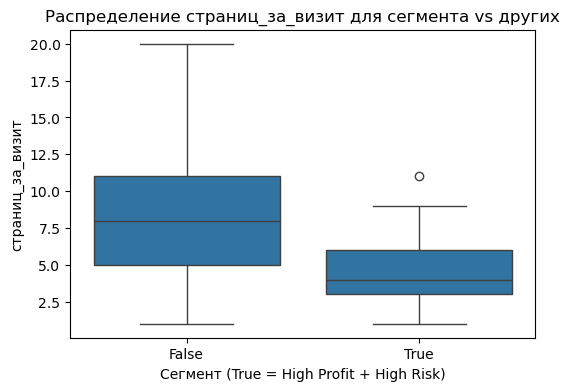

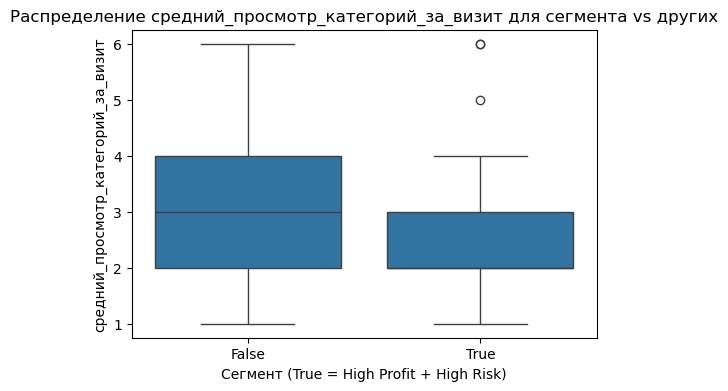

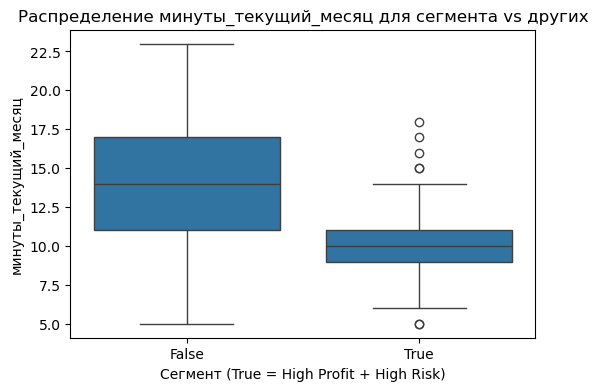

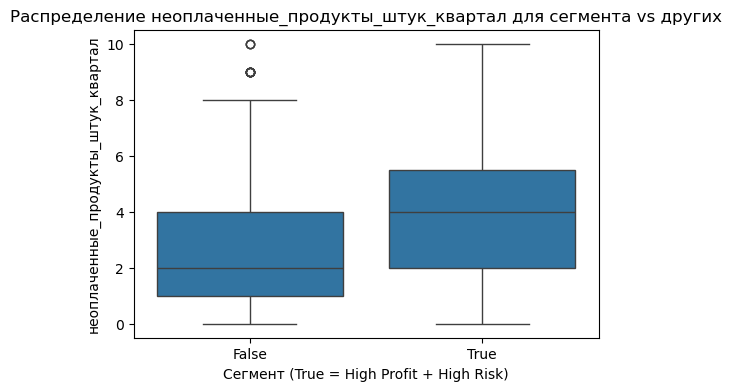

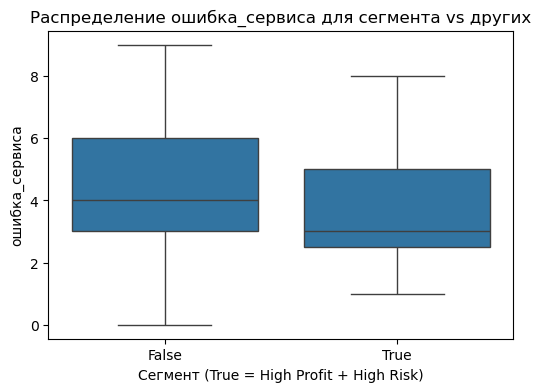

In [104]:
features_to_compare = [
    'страниц_за_визит',
    'средний_просмотр_категорий_за_визит',
    'минуты_текущий_месяц',
    'неоплаченные_продукты_штук_квартал',
    'ошибка_сервиса'
]

for col in features_to_compare:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df['segment'] == 'High Risk | High Profit', y=df[col])
    plt.title(f"Распределение {col} для сегмента vs других")
    plt.xlabel("Сегмент (True = High Profit + High Risk)")
    plt.show()


**анализ сегмента (High Profit + High Risk)**
1. Страницы за визит
    - Сегмент смотрит меньше страниц, чем остальные - вовлечённость падает.
**Вывод:** интерес к товарам снижен, клиент тратит меньше времени на поиск.

2. Средний просмотр категорий
    - Сегмент просматривает меньше категорий - узкий фокус, низкое исследовательское поведение.
**Вывод:** клиенты не ищут новые товары, возможно, не находят нужное.

3. Минуты за визит (текущий месяц)
    - У сегмента меньше времени на сайте, чем у остальных.
**Вывод:** общее вовлечение падает — сильный сигнал снижения активности.

4. Неоплаченные товары
    - Заметно больше неоплаченных товаров в корзине.
**Вывод:** высокая доля незавершённых покупок, возможные причины:
        - неудобство оформления,
        - сомнения в цене,
        - не нашли нужный вариант,
        - отвлекающие ошибки.
        
5. Ошибка сервиса
    - Ошибок не больше, чем у остальных.
**Вывод:** ухудшение активности — не следствие технических проблем.

### Проверка динамики поведения (текущий vs предыдущий месяц)

#### Время на сайте:

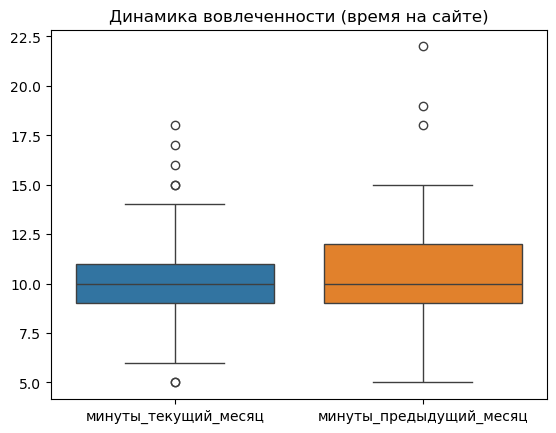

In [105]:
sns.boxplot(
    data=target_segment[['минуты_текущий_месяц', 'минуты_предыдущий_месяц']]
)
plt.title("Динамика вовлеченности (время на сайте)")
plt.show()


**На графике видно, что:**
- Среднее время на сайте в текущем месяце чуть ниже, чем в предыдущем.
- Разброс значений тоже снизился — меньше пользователей проводят много времени на сайте.

**Это указывает на падение вовлечённости: клиенты входят реже, проводят меньше времени и реже “залипают” в контенте или каталоге.**

#### Выручка:

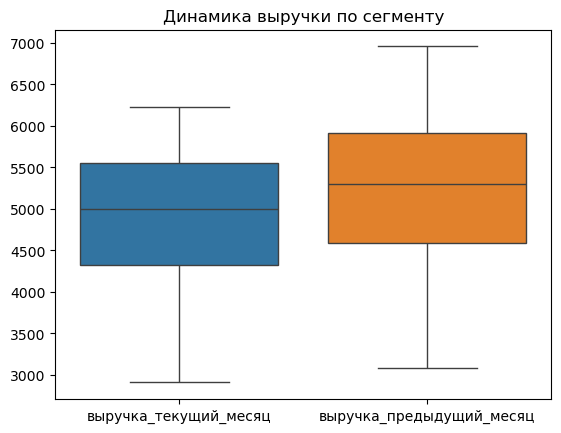

In [106]:
sns.boxplot(
    data=target_segment[['выручка_текущий_месяц', 'выручка_предыдущий_месяц']]
)
plt.title("Динамика выручки по сегменту")
plt.show()


**Сегмент “High Profit + High Risk” демонстрирует первые признаки спада дохода:**
- медиана ниже
- максимумы ниже
- есть клиент с выручкой ≈ 0 в текущем месяце.

**Это подтверждает риск ухода: сегмент сохраняет хорошую прибыльность, но уже показывает негативную динамику по выручке, что усиливает необходимость удерживающих мер.**

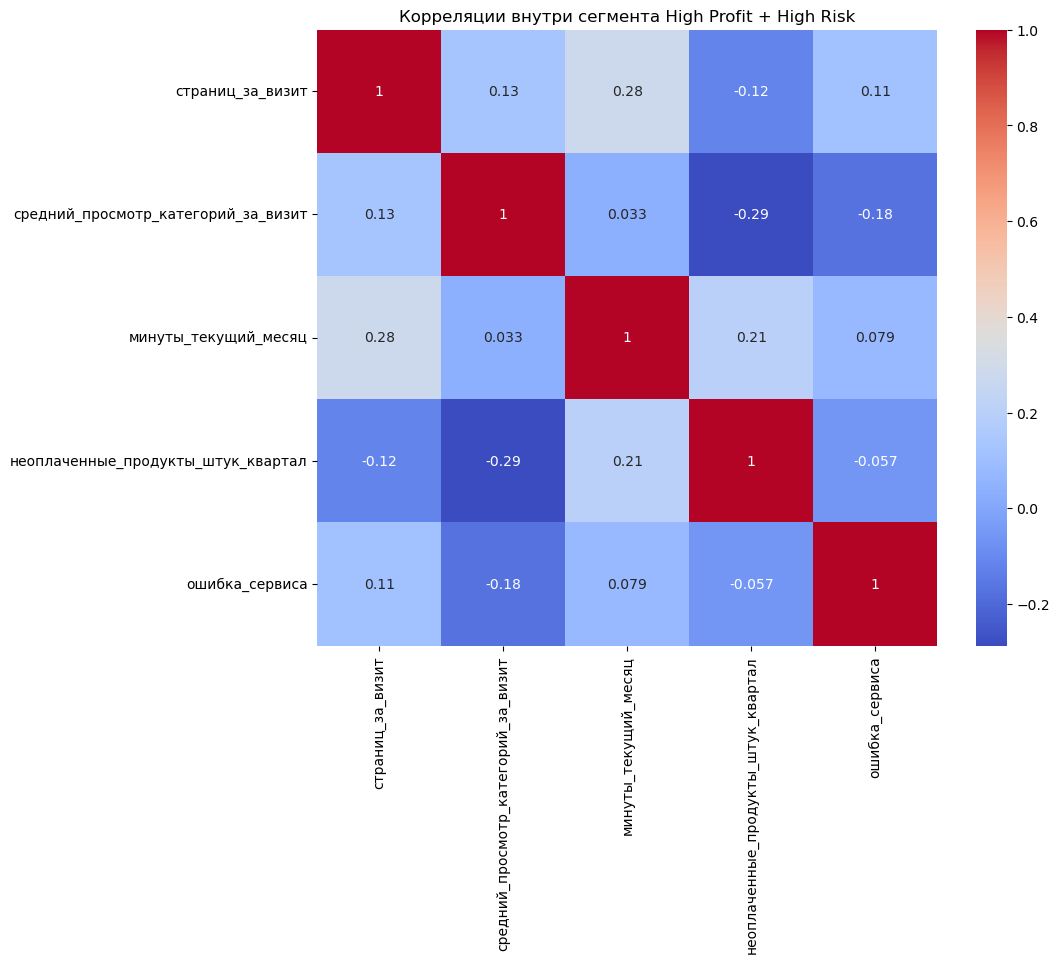

In [107]:
plt.figure(figsize=(10,8))
sns.heatmap(target_segment[features_to_compare].corr(), annot=True, cmap='coolwarm')
plt.title("Корреляции внутри сегмента High Profit + High Risk")
plt.show()

**Корреляции очень слабые - сегмент неоднородный**

**Почти все коэффициенты лежат в диапазоне от –0.3 до +0.25.<br>
Это значит:**
- внутри сегмента нет одного универсального паттерна поведения;
- клиенты приходят к высокой прибыльности и высокому риску разными путями (кто-то смотрит мало страниц, кто-то много, у кого-то много неоплаченных товаров и т.д.).

**сегмент требует персонализированного подхода, а не одного единого решения.**

### Выводы о сегментах и предложенные рекомендации

Мы сосредоточились на группе High Profit + High Risk — это клиенты, которые:
- дают высокую прибыль,
- у них высокая вероятность снижения покупательской активности.

**Это самые ценные, но одновременно самые нестабильные покупатели.**

**Основные наблюдения по сегменту**
1. Клиенты проводят меньше времени на сайте
    -Время на сайте в текущем месяце ниже, чем в предыдущем.
    -Сегмент тратит меньше минут, чем другие пользователи.
- Это сигнал падающей вовлечённости.

2. Глубина просмотра также ниже нормы
- Меньше страниц_за_визит,
- Меньше просмотренных категорий.
-  Клиент «не погружается» в ассортимент, быстро уходит.

3. Количество неоплаченных товаров у сегмента выше
- Брошенные корзины встречаются значительно чаще.
- Это может указывать на сомнения, неудобный путь к оплате или слишком сложную навигацию.
-  Это ключевой фактор уровня риска.

4. Ошибки сервиса не являются основной причиной
- Внутри сегмента влияние ошибок сервиса слабое.
- Но мелкое негативное влияние на вовлечённость всё же присутствует.
- Технические проблемы не критичны, но полностью игнорировать их нельзя.

5. Внутренние корреляции слабые
- Сегмент неоднородный — нет единого поведения.
- Это требует персонализированных решений.

**Предложения по работе с сегментом и почему они выбраны**
1. Упростить путь к покупке (против брошенных корзин)

**Так как в сегменте повышено количество неоплаченных товаров,необходимы предлогаемые меры:**

- Прямые напоминания о брошенной корзине (email, push).
- Купон «–5% за завершение покупки».
- Укороченный путь к оплате для повторных покупателей.
- Автоматическое сохранение корзины и быстрого оформления.

**Почему:**
-  это наиболее вероятная причина ухода: товар уже добавлен, но покупка не завершается.

2. Повысить вовлечённость через персонализацию

**Так как клиенты мало просматривают страниц и категорий:**

**Предложения:**

- Лента рекомендаций на основе истории покупок.
- Индивидуальные подборки «Вам может понравиться».

**Почему:**
- помогает компенсировать низкое вовлечение и увеличивать вероятность покупки.

3. Стабилизировать интерес через вознаграждения

**У сегмента высокая прибыльность - значит он покупает активно, но нестабильно.**

**Предложения:**

- Маленькие персональные бонусы за регулярные покупки.
- Программа микро-лояльности: накопительные скидки.
- Специальные акции только для группы.

**Почему:**
- удержание прибыльного клиента окупается гораздо больше, чем привлечение нового.

4. Лёгкая работа с возражениями

**Так как ошибки сервиса не доминируют, но присутствуют незначительные негативные связи:**

**Предложения:**

- Быстрое решение инцидентов через чат или Telegram-бота.
- Компенсации для клиентов, у которых были ошибки при оформлении.

**Почему:**
- позволяет удерживать клиентов, у которых могли быть негативные мелкие раздражения.

### Промежуточный вывод по сегментации и рекомендации

**В рамках шага 8 был выполнен анализ покупателей с учётом модели и данных о прибыльности:**

**Провели сегментацию и выделили группу High Profit + High Risk — ценных клиентов, у которых высокая вероятность снижения активности.**

**Исследовали сегмент с помощью визуального и аналитического сравнения ключевых признаков:**
- время на сайте,
- глубина просмотра,
- количество неоплаченных товаров,
- ошибки сервиса,
- динамика выручки.

**Выявили основные проблемы:**

- сниженная вовлечённость (меньше времени и просмотров),
- рост числа брошенных корзин,
- лёгкое снижение выручки,
- слабая корреляция внутри сегмента — неоднородность поведения.

**Сформулировали рекомендации по работе с сегментом:**

- сокращение количества брошенных корзин (напоминания, скидки, упрощение оплаты),
- повышение вовлечённости персонализированными подборками,
- программа удержания прибыльных клиентов (бонусы, индивидуальные акции),
- оперативное устранение мелких технических ошибок.

**Итог: выбранный сегмент требует адресной, персонализированной коммуникации и оптимизации пользовательского пути. Это позволит сохранить клиентов, которые при уходе создают наибольшие потери.**

## Итоговые выводы
**Описание предоставленных данных и их качество**

Для исследования было предоставлено четыре таблицы, каждая из которых отражает отдельную сторону поведения клиентов:

1. market_file.csv — основная информация о покупателях:
    - поведенческие признаки,
    - категория покупок,
    - маркетинговые взаимодействия,
    - ошибки сервиса,
    - характеристики посещений сайта.
2. market_money.csv — данные о выручке за предыдущий, текущий и предпредыдущий месяцы.
3. market_time.csv — время, проведённое на сайте, по тем же периодам.
4. money.csv — прибыльность клиентов за последние три месяца (для сегментации).

**Качество данных**

- Пропусков и дублей не обнаружено.
- Типы данных соответствуют смыслу признаков.
- Выявлены орфографические и форматные ошибки в категориальных значениях
-  проведено исправление.
- Столбцы приведены к единому стилю (snake_case, нижний регистр).
- Периодические таблицы корректно объединены и развернуты по колонкам.

**Что выполнено в рамках предобработки и анализа**

- Данные загружены, изучены и проверены на соответствие описанию.
- Исправлены ошибки в категориях, приведены типы.
- Все таблицы объединены по id; периоды выручки и времени вынесены в отдельные признаки.
- Проведён подробный EDA:
    - распределения числовых признаков,
    - частоты категорий,
    - боксплоты и гистограммы,
    - анализ выбросов,
    - оценка корреляций,
    - первичное понимание поведения клиентов.
- Обнаружено, что большинство признаков имеют значимую бизнес-нагруженность, а некоторые слабые связи подтверждают необходимость машинного моделирования.

**Объединение данных и подготовка признаков**

Были объединены три ключевые таблицы:

- market_file — поведение и характеристики покупателей;
- market_money — данные о выручке по периодам;
- market_time — время на сайте по периодам.


**Результаты работы моделей**

**Препроцессинг**

Для числовых и категориальных признаков использованы два варианта обработки (StandardScaler + OneHotEncoder и MinMaxScaler + OrdinalEncoder), что позволило максимизировать качество моделей и выполнить требования проекта.

**Модели классификации (цель — предсказать снижение активности)**

Обучены четыре модели: KNN, DecisionTree, Logistic Regression и SVC.
Для каждой выполнен подбор гиперпараметров с метрикой ROC-AUC.

**Лучший результат:**

- Logistic Regression — ROC-AUC ≈ 0.902,

Победителем стала Logistic Regression, но использованная модель для SHAP-анализа -Logistic Regression

**Интерпретация модели и SHAP-анализ**

SHAP выделил ключевые признаки:

1. страницы_за_визит
2. средний_просмотр_категорий_за_визит
3. акционные_покупки
4. минуты_текущий_месяц
5. неоплаченные_продукты_штук_квартал

Именно падение вовлечённости и рост незавершённых корзин являются основными факторами снижения активности.

**Сегментация и бизнес-рекомендации**

Сформирован приоритетный сегмент:

**High Profit + High Risk**

**Выявлено:**
- Падение времени на сайте,
- Снижение глубины просмотра,
- Рост неоплаченных корзин,
- Начало снижения выручки,
- Нет критических ошибок сервиса,
- Поведение сегмента неоднородно (низкие корреляции).

**Предложения:**
- Персонализированные рекомендации,
- Оптимизация оформления заказа,
- Напоминания о корзине,
- Удерживающие акции и бонусы,
- Контроль сервисных ошибок для отдельных пользователей.

**Выводы о моделях**

- SVC — лучшая модель, способная качественно отделять клиентов с риском снижения активности.
- Модель даёт возможность раннего обнаружения клиентов в зоне риска.

**Главный итог**

**Проект успешно решает поставленную задачу:**

- Данные очищены, объединены и детально проанализированы.
- Построены и настроены модели, выбран оптимальный классификатор.
- Проведена интерпретация предсказаний и выделен критически важный сегмент.
- Сформулированы практические рекомендации для работы с сегментом, который приносит максимально возможную прибыль, но нуждается в удержании.

**Результат позволяет компании системно управлять риском снижения активности, оптимизировать маркетинговые усилия и увеличить долгосрочную ценность клиентов.**